In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,  VotingClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report
import ast
import numpy as np
from xgboost import XGBClassifier
import pandas as pd

df = pd.read_csv("dhhпарdfh.csv", sep=';')
# print(df.dtypes)
df['val_acc'] = df['val_acc'].map(ast.literal_eval)
df['train_acc']= df['train_acc'].map(ast.literal_eval)
df['test_acc']= df['test_acc'].map(ast.literal_eval)
# print(df.head(5))
# print(df.dtypes)
# df.head()

df = df[df['train_acc'].apply(lambda x: len(x) == 30)]


In [3]:
import numpy as np

def create_sequences(df, min_input=5, max_input=30):
    """
    Создаём (X, Y) для обучения seq2seq RNN.
    X: первые k эпох (train_acc, val_acc)
    Y: следующая эпоха (train_acc, val_acc, test_acc)
    """
    X_list = []
    Y_list = []

    for _, row in df.iterrows():
        train = np.array(row["train_acc"])
        val   = np.array(row["val_acc"])
        # test  = np.array(row["test_acc"])

        n_epochs = len(train)

        for k in range(min_input, n_epochs):
            x = np.stack([train[:k], val[:k]], axis=1)   # (k,2)
            y = np.array([train[k], val[k]])    # (3,)
            X_list.append(x)
            Y_list.append(y)

    return X_list, np.array(Y_list)


from tensorflow.keras.preprocessing.sequence import pad_sequences

X_list, Y = create_sequences(df)

# pad sequences до максимальной длины (30)
X = pad_sequences(X_list, maxlen=30, dtype='float32', padding='pre', truncating='pre')
# X.shape -> (samples, 30, 2)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking, GRU

model = Sequential([
    Masking(mask_value=0., input_shape=(30,2)),  # чтобы padding не мешал
    GRU(64, activation='tanh'),
    # GRU(64, activation='tanh'),

    Dense(32, activation='relu'),
    Dense(2)  # train_acc, val_acc, test_acc
])

model.compile(optimizer='adam', loss='mse')
model.summary()

D:\MyPrograms\python\pis_hh\.venv\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 30, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,202 (59.38 KB)

 Trainable params: 15,202 (59.38 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    X_train,
    Y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0747 - val_loss: 0.0021
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0012 - val_loss: 6.7812e-04
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6380e-04 - val_loss: 3.6131e-04
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.3088e-04 - val_loss: 3.0571e-04
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.0055e-04 - val_loss: 2.8428e-04
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.8428e-04 - val_loss: 2.9602e-04
Epoch 7/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.7545e-04 - val_loss: 2.6455e-04
Epoch 8/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6671e-04 - val_loss: 2.5656e-04
Epoch 9/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5802e-04 - val_loss: 2.4520e-04
Epoch 10/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.5828e-04 - val_loss: 2.3909e-04
Epoch 11/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.4505e-04 

In [7]:
def autoregressive_predict(model, x_init, n_steps=30):
    """
    x_init: массив (k,2) первых эпох
    n_steps: сколько эпох генерировать вперед
    """
    import copy
    x_seq = copy.deepcopy(x_init)
    preds = []

    for _ in range(n_steps):
        # pad до 30
        x_input = np.zeros((1,30,2))
        x_input[0,-x_seq.shape[0]:,:] = x_seq  # последние k шагов

        y_pred = model.predict(x_input, verbose=0)[0]  # (3,)
        preds.append(y_pred)

        # добавить предсказание в последовательность
        x_seq = np.vstack([x_seq, y_pred[:2]])

    return np.array(preds)  # (n_steps,3)

[[0.02       0.13500001]
 [0.18000001 0.161     ]
 [0.25999999 0.183     ]
 [0.36000001 0.197     ]
 [0.36000001 0.20999999]
 [0.41999999 0.215     ]
 [0.47999999 0.233     ]
 [0.5        0.245     ]
 [0.56       0.266     ]
 [0.56       0.27900001]
 [0.57999998 0.294     ]
 [0.63999999 0.31200001]
 [0.66000003 0.329     ]
 [0.69999999 0.34599999]
 [0.69999999 0.37599999]
 [0.72000003 0.40599999]
 [0.80000001 0.43399999]
 [0.80000001 0.454     ]
 [0.81999999 0.46200001]
 [0.86000001 0.48100001]
 [0.86000001 0.48899999]
 [0.88       0.50199997]
 [0.88       0.51499999]
 [0.88       0.51599997]
 [0.92000002 0.52399999]
 [0.95999998 0.52499998]
 [0.95999998 0.53200001]
 [0.98000002 0.53399998]]
[[0.9852022  0.54662055]
 [0.99570173 0.5577159 ]]


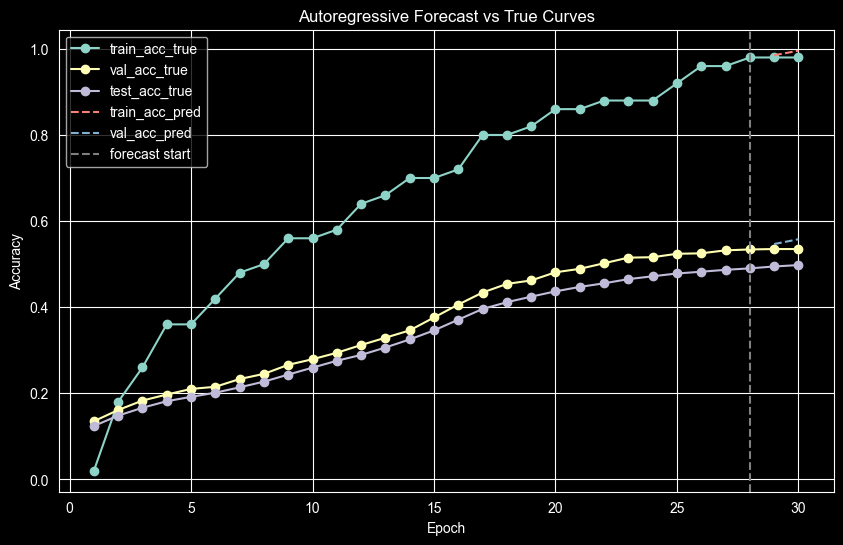

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# берем первую модель из df
row = df.iloc[3]

# настоящие кривые
train_true = np.array(row["train_acc"])
val_true   = np.array(row["val_acc"])
test_true  = np.array(row["test_acc"])

# первые k эпох на вход
k = 28
x_init = np.stack([train_true[:k], val_true[:k]], axis=1)  # (k,2)

print(x_init)
preds = autoregressive_predict(model, x_init, n_steps=len(train_true)-k)
print(preds)
# построим кривые
epochs_full = np.arange(1, len(train_true)+1)

plt.figure(figsize=(10,6))

# Истинные кривые
plt.plot(epochs_full, train_true, 'o-', label='train_acc_true')
plt.plot(epochs_full, val_true, 'o-', label='val_acc_true')
plt.plot(epochs_full, test_true, 'o-', label='test_acc_true')

# Прогнозные кривые
plt.plot(epochs_full[k:], preds[:,0], '--', label='train_acc_pred')
plt.plot(epochs_full[k:], preds[:,1], '--', label='val_acc_pred')
# plt.plot(epochs_full[k:], preds[:,2], '--', label='test_acc_pred')

plt.axvline(k, color='gray', linestyle='--', label='forecast start')  # где начинается прогноз
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Autoregressive Forecast vs True Curves')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

k_values = range(3, 21)
metrics = []

for k in k_values:
    maes = {'train_acc': [], 'val_acc': [], 'test_acc': []}
    rmses = {'train_acc': [], 'val_acc': [], 'test_acc': []}

    for i, row in df.iterrows():  # gr — ваш датасет
        print(i)
        train_true = np.array(row['train_acc'])
        val_true   = np.array(row['val_acc'])
        test_true  = np.array(row['test_acc'])


        x_init = np.stack([train_true[:k], val_true[:k]], axis=1)  # (k,2)
        preds = autoregressive_predict(model, x_init, n_steps=len(train_true)-k)
        try:
            # Метрики
            maes['train_acc'].append(mean_absolute_error(train_true[k:], preds[:,0]))
            maes['val_acc'].append(mean_absolute_error(val_true[k:], preds[:,1]))
            # maes['test_acc'].append(mean_absolute_error(test_true[k:], preds[:,2]))

            rmses['train_acc'].append(np.sqrt(mean_squared_error(train_true[k:], preds[:,0])))
            rmses['val_acc'].append(np.sqrt(mean_squared_error(val_true[k:], preds[:,1])))
            # rmses['test_acc'].append(np.sqrt(mean_squared_error(test_true[k:], preds[:,2])))
        except:
            print(preds)
            break
        if i >= 10*30:
            break
    metrics.append({
        'k': k,
        'mae_train': np.mean(maes['train_acc']),
        'mae_val': np.mean(maes['val_acc']),
        'mae_test': np.mean(maes['test_acc']),
        'rmse_train': np.mean(rmses['train_acc']),
        'rmse_val': np.mean(rmses['val_acc']),
        'rmse_test': np.mean(rmses['test_acc']),
    })



metrics_df = pd.DataFrame(metrics)
print(metrics_df)

29
59
89
119
149
179
209
239
269
299
329


D:\MyPrograms\python\pis_hh\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
D:\MyPrograms\python\pis_hh\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


29
59
89
119
149
179
209
239
269
299
329


D:\MyPrograms\python\pis_hh\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
D:\MyPrograms\python\pis_hh\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


29
59
89
119
149
179
209
239
269
299
329


...

D:\MyPrograms\python\pis_hh\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
D:\MyPrograms\python\pis_hh\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


29
59
89
119
149
179
209
239
269
299
329


D:\MyPrograms\python\pis_hh\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
D:\MyPrograms\python\pis_hh\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


29
59
89
119
149
179
209
239
269
299
329
     k  mae_train   mae_val  mae_test  rmse_train  rmse_val  rmse_test
0    3   0.091641  0.131920       NaN    0.100096  0.138752        NaN
1    4   0.087734  0.114801       NaN    0.095147  0.121491        NaN
2    5   0.084804  0.101218       NaN    0.091417  0.107565        NaN
3    6   0.081963  0.089338       NaN    0.087687  0.095597        NaN
4    7   0.077959  0.082338       NaN    0.083580  0.088774        NaN
5    8   0.073003  0.073322       NaN    0.078376  0.080006        NaN
6    9   0.070323  0.068002       NaN    0.075522  0.074840        NaN
7   10   0.065648  0.068106       NaN    0.070579  0.075211        NaN
8   11   0.061885  0.067303       NaN    0.067167  0.074511        NaN
9   12   0.059610  0.067499       NaN    0.065310  0.074714        NaN
10  13   0.058233  0.064367       NaN    0.063232  0.072068        NaN
11  14   0.056285  0.060304       NaN    0.060908  0.067703        NaN
12  15   0.051910  0.061728       Na

D:\MyPrograms\python\pis_hh\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
D:\MyPrograms\python\pis_hh\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


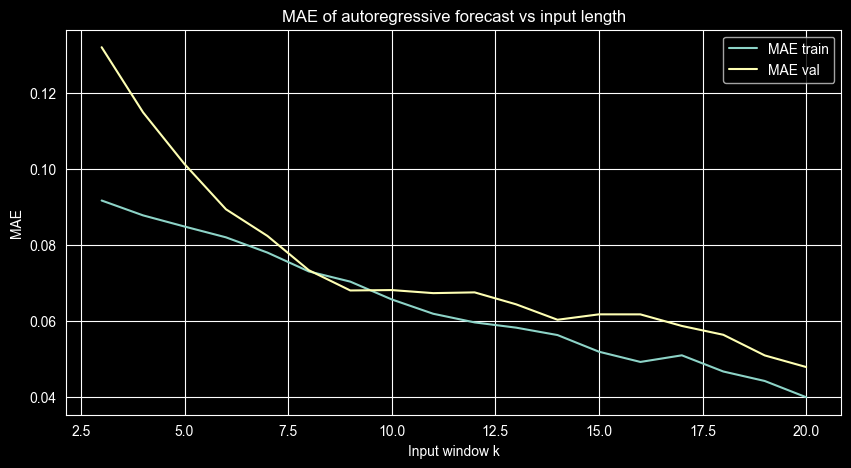

In [10]:
import matplotlib.pyplot as plt
metrics_df = pd.DataFrame(metrics)
metrics_df.head()
plt.figure(figsize=(10,5))
plt.plot(metrics_df['k'], metrics_df['mae_train'], label='MAE train')
plt.plot(metrics_df['k'], metrics_df['mae_val'], label='MAE val')
plt.xlabel('Input window k')
plt.ylabel('MAE')
plt.title('MAE of autoregressive forecast vs input length')
plt.legend()
plt.grid(True)
plt.show()